*Acknowledgments: This notebook borrows material from a textbook from Stuart Coles (2001) and notebooks from Jorn Mossel and Climematch. Finally, trend detection follows the work of World Weather Attribution to Malacca Strait.*

# Introduction

At the end of November 2025, Sumatra was devastated by exceptional monsoon rains and a rare tropical storm by Cyclone Senyar. This triggers massive flooding, flash floods, and widespread landslides across provinces with more than 3.2–3.3 million people have been affected. Given the high impact damage, we might ask **is such an extreme event statistically to happen once in a while (say every 100 years)**, or **is this an indication of a changing climate**.

## What is a hunderd year event? (defining an extreme event)

Whenever we observe an extreme event the question is, is this an infrequent event but statistically probable. Or is this an "outlier", a sign that the system has changed and hence the past is no relevant for the future.

So what we want to quantity is, for a given return period (eg 100 years), what extreme values do we expect to observe. The terminology "100-year return level" means a value that is expected to be exceeded exactly once in the next 100 years. We quickly sketch two possible approaches:

### Ideal Scenario

If we have access to the exact probablity distribtion we can just read off which values correspond to infrequent events. In practice we rarely ever know the probablity distribition with sufficient accuracy. Alternatively, if we have sufficient data, say 10,000 years of historical data a 100 year event can simply be estimated as the 99-th percentile. Pretty straightforward, but in practice we rarely encounter time series with sufficient history. Also we are assuming that the we can describe the time series with the same statistical model over its entire history.

### Extreme Value Theory (fitting the tails)

For most use cases we have much less data. For example if we have only 100 years of data, it's tempting to take the most extreme value observed and call that the 100 year event (this is sometimes done in the media). Not only is this method wastefull with data, we ignore all observations but one, but also leads to huge estimation errors. Instead we can use extreme value theory, to fit a statistical distribution for extreme observations only. Not only is this method more robust it also allows us to do extrapolation. For example if we have only 100 years of data we can still use the fitted distribution to make predictions of what a 200 years event would be. This notebook demonstrates how extreme value theory can be used for extreme rainfall data.

# Preparing the Data

In [27]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# TODO: Plot defined event domain!

We will be using ERA5 daily data over defined this defined region. We will use area-averaged Rx5day which can be easily computed using CDO commands.

```
cdo fldmean era_tp_sumatra.nc era5_tp_sumatra_fldmean.nc
cdo shifttime,6mon -yearmax -runsum,5 -shifttime,-6mon era5_tp_sumatra_fldmean.nc rx5day_sumatra.nc
```

In [41]:
# Open file for Rx5day
ds = xr.open_dataset("../../data/era5_daily_tp/rx5day_sumatra.nc")

# Take precipitation variable and convert unit
pr = ds['tp'] * 1_000

# Convert to DataFrame
df = pr.to_dataframe().reset_index()[['valid_time', 'tp']]
df = df[1:] # remove first row (shift excess)
df['year'] = df['valid_time'].dt.year

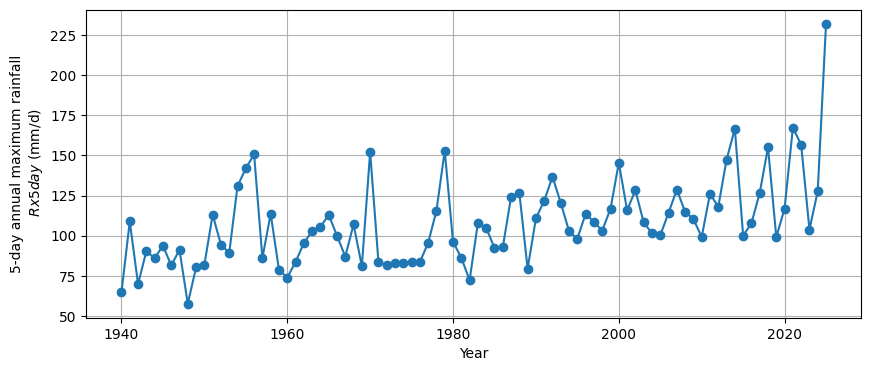

In [43]:
# Plot time series for Rx5day
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(df['year'], df['tp'], '-o')
plt.xlabel('Year')
plt.ylabel('5-day annual maximum rainfall\n $Rx5day$ (mm/d)')
# plt.title('Area-averaged Rx5day over defined region in Sumatra')
plt.grid()
plt.show()

# Stationary Fit

# Non-Stationary Fit